# $\mathrm{U}(1)$ Gauge Theory in 2D

## Introduction

An important area within lattice field theory deals with simulating _gauge fields_ on the lattice. \
Notable examples include:
* Quantum Chromodynamics, where the gauge fields are associated with the (Lie) group $\mathrm{SU(3)}$ (complex unitary $3 \times 3$ matrices with unit determinant) and its (Lie) algebra.
* Large-$N$ Yang-Mills theories, where the relevant groups are $\mathrm{SU}(N)$ for different degrees $N$.

In these exercises, we will study the simplest unitary group, the group $\mathrm{U(1)}$, in 2 dimensions.

A simple action for $\mathrm{SU}(N)$ gauge fields is given by the Wilson action,
\begin{equation}
    S[U]
    =
    \frac{\beta}{N} \sum_{n \in \varLambda} \sum_{\mu < \nu} \mathrm{Re} \left\{ \mathrm{tr}\left[1 - U_{\mu \nu}(n) \right] \right\},
\end{equation}
where $\beta$ is the inverse coupling, $\varLambda$ denotes the nodes of the lattice, $1$ represents the $N \times N$ identity matrix, and $U_{\mu \nu}(n)$ is the _plaquette_, an oriented product of four links given by
\begin{equation}
    U_{\mu \nu}(n)
    =
    U_{\mu}(n) U_{\nu}(n + \hat{\mu}) U^{\dagger}_{\mu}(n + \hat{\nu}) U_{\nu}^{\dagger}(n).
\end{equation}
For $\mathrm{U}(1)$, the elements of the group have the form $U_{\mu}(n) = \mathrm{e}^{i \theta_{\mu}(n)}$, where $\theta \in [-\pi, \pi)$, so the plaquette can be written as
\begin{equation}
    U_{\mu \nu}(n)
    =
    \exp{
        \left\{ i
        \left[
        \theta_{\mu}(n) + \theta_{\nu}(n + \hat{\mu}) - \theta_{\mu}(n + \hat{\nu}) - \theta_{\nu}(n) \right]
        \right\}}
    :=
    \mathrm{e}^{i \theta_{\mu \nu}(n)}.
\end{equation}
Then, the action can be simplified to
\begin{equation}
    S[\theta] = \beta \sum_{n \in \varLambda} \sum_{\mu < \nu} \left[ 1 - \cos{\theta_{\mu \nu}(n)} \right].
\end{equation}
In 2 dimensions, we have $0 \leq \mu, \nu \leq 1$, and therefore
\begin{equation}
    \boxed{S[\theta] = \beta \sum_{n \in \varLambda} \left[ 1 - \cos{\theta_{0 1}(n)} \right]}
\end{equation}
with
\begin{equation}
    \boxed{\theta_{0 1}(n) = \theta_{0}(n) + \theta_{1}(n + \hat{0}) - \theta_{0}(n + \hat{1}) - \theta_{1}(n).}
\end{equation}
Hence, rather than working with the links $U_{\mu}(n)$ themselves, we will work with the phases $\theta_{\mu}(n)$.

## 1. Implementing Functions

In two dimensions we have $\mu \in \{ 0, 1\}$, and for each of these values we have an angle _at every site of the lattice_ (using periodic boundary conditions). \
From this, a convenient representation of $\theta_{\mu}(n)$ is as an array of shape $(2, L_{x}, L_{y})$. \
With this representation, if the array's name is `angles`, we have
* $\theta_{0}(0, 0)$ -> `angles[0, 0, 0]`,
* $\theta_{0}(1, 0)$ -> `angles[0, 1, 0]`,
* $\theta_{0}(0, 1)$ -> `angles[0, 0, 1]`,
* etc.

### 1.1 Computing the action

With the above array representation in mind, implement the following functions:
1. Using NumPy's `np.roll`, implement a function that computes all the plaquettes angles $\theta_{\mu \nu}(n)$.
2. Implement another function that computes the action, calling your function in 1 to compute the plaquettes angles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def compute_plaquettes_angles(angles: np.ndarray):
    theta = (angles[0]
        + np.roll(angles[1], shift=-1, axis=0)
        - np.roll(angles[0], shift=-1, axis=1)
        - angles[1])
    return theta

def compute_action(angles: np.ndarray, beta: float):
    theta = compute_plaquettes_angles(angles)
    action = beta * np.sum(1 - np.cos(theta))
    return action

Check your implementation of the action by running the cell below

In [3]:
test_rng = np.random.default_rng(seed=42)
test_angles = (2 * np.pi) * test_rng.random(size=(2, 16, 16)) - np.pi
test_action = compute_action(test_angles, beta=0.25)
assert isinstance(test_action, float), \
    "Result of action is not a floating point number. Did you sum over all sites?"
assert np.isclose(test_action, 62.5319286, rtol=0.0, atol=1e-7), \
    f"Wrong value of the action. Got {test_action:.10f} instead of 62.531928621."
print("Tests passed!")

Tests passed!


### 1.2 Topological charge

An important quantity in $\mathrm{SU}(N)$ gauge theories is the _topological charge_. \
As stated in the name, this charge is related to the topology of the configurations in the theory. \
In particular, for pure gauge theories as the one we are studying here, this “charge” helps us understand the topology of the vacuum.

For the purpose of these exercises, we will limit ourselves to one phenomenon related to the topological charge, so we will need to measure it.

In $\mathrm{U}(1)$, _one_ possible definition of the topological charge is given by
\begin{equation}
    Q = \sum_{n \in \varLambda} \mathrm{round}\left( \frac{\theta_{0 1}}{2 \pi} \right).
\end{equation}
In words, the topological charge measures how many times each plaquette “completes a circle around its center”.

Implement a function to compute the topological charge below, using your previous function to compute the plaquettes angles.

In [4]:
def compute_topological_charge(angles: np.ndarray):
    theta = compute_plaquettes_angles(angles)
    charge = np.sum(np.round(theta/(2*np.pi)))
    return charge

Check your implementation by running the cell below.

In [5]:
test_rng = np.random.default_rng(seed=42)
test_angles = (2 * np.pi) * test_rng.random(size=(2, 16, 16)) - np.pi
test_Q = compute_topological_charge(test_angles)
assert test_Q == 6, "Wrong value for the topological charge."
print("Test passed!")

Test passed!


## 2. Gauge Invariance

In gauge field theories, a common feature is that certain quantities must be by construction _gauge invariant_. \
In other words, these quantities are unchanged when the links are transformed as
\begin{equation}
    U_{\mu}(n) \to U'_{\mu}(n) = \Omega(n) U_{\mu}(n) \Omega^{\dagger}(n + \hat{\mu}),
\end{equation}
where $\Omega(n)$ is any element of the same group as the links.

Two examples of gauge invariant quantities are the action $S$ and the topological charge $Q$. \
Check that this is indeed the case by implementing a gauge transformation in the code cell below. \
Note that, since we are dealing with the links' phases rather than the links themselves, the gauge transformation reads
\begin{equation}
    \theta_{\mu}(n) \to \theta'_{\mu}(n) = \omega(n) + \theta_{\mu}(n) - \omega(n + \hat{\mu}), \qquad \omega(n) \in \left[-\pi, \pi \right).
\end{equation}

In [6]:
test_rng = np.random.default_rng(seed=42)
test_angles = (2 * np.pi) * test_rng.random(size=(2, 16, 16)) - np.pi
test_omegas = (2 * np.pi) * test_rng.random(size=(16, 16)) - np.pi
print(f"Initial action: {compute_action(test_angles, beta=0.25):.6f}")
print(f"Initial charge: {compute_topological_charge(test_angles):.0f}")

# TODO: Implement here the transformation...
transformed_angles = test_angles.copy()
transformed_angles[0] = test_angles[0] + test_omegas - np.roll(test_omegas, shift=-1, axis=0) # we need plus instead of multiplication since we deal with the links themselves (not the U matrices)
transformed_angles[1] = test_angles[1] + test_omegas - np.roll(test_omegas, shift=-1, axis=1)

# TODO: Check that the results below are the same as the initial ones.
print(f"Changed action: {compute_action(transformed_angles, beta=0.25):.6f}")
print(f"Changed charge: {compute_topological_charge(transformed_angles):.0f}")

Initial action: 62.531929
Initial charge: 6
Changed action: 62.531929
Changed charge: 6


## 3. Topological Freezing

For _any_ theory on the lattice, an essential part of Markov Chain Monte Carlo methods is to be able to sample the target distribution properly, i.e., without bias. \
In order to do so, the chosen proposal function must be capable of exploring all the configurations allowed. \
Unfortunately, this is not always easy, and the behavior of the algorithm may drastically change as we explore different values of the parameters of the theory.

For gauge theories, a common problem related to this is that of _topological freezing_: As $\beta$ increases, many proposal functions are unable to sample from all topological sectors, i.e., they are unable to explore configurations with different values of $Q$. \
 This is a problem because increasing $\beta$ leads to smaller lattice spacings, that is, improves the resolution of the lattice, so we want to be able to increase $\beta$ without biasing the distribution.

In this exercise, you will see how topological freezing appears in the theory, by looking at the behavior of the topological charge for different values of $\beta$.

### Setup

In [7]:
def propose_angles(angles: np.ndarray, width: float, rng: np.random.Generator) -> np.ndarray:
    delta_angles = 2. * rng.random(size=angles.shape) - 1.
    proposed_angles = angles + width * delta_angles
    # Make sure that the final values are within the interval [-pi, pi).
    proposed_angles = ((proposed_angles + np.pi) % (2 * np.pi)) - np.pi
    return proposed_angles


def metropolis_step(angles: np.ndarray,
                    beta: float,
                    width: float,
                    rng: np.random.Generator):
    # 1. Proposal
    proposed_angles = propose_angles(angles, width, rng)

    # 2. Acceptance probability.
    current_action = compute_action(angles, beta=beta)
    proposed_action = compute_action(proposed_angles, beta=beta)
    p_acceptance = np.min([1.0, np.exp(current_action - proposed_action)])

    # 3. Accept / reject
    r = rng.random()

    if r <= p_acceptance:  # Accept.
        return proposed_angles, 1

    # Reject.
    return angles, 0


def sample_field(initial_angles: np.ndarray,
                 num_samples: int,
                 beta: float,
                 width: float,
                 rng: np.random.Generator):
    angles = initial_angles
    charges = []
    acceptance = []

    for _ in range(num_samples):
        angles, accepted = metropolis_step(angles=angles, beta=beta, width=width, rng=rng)
        charges.append(compute_topological_charge(angles=angles))
        acceptance.append(accepted)

    return charges, acceptance

### 3.1 Tuning

For each value of $\beta$ below, find the approximate width that leads to an acceptance rate of $65-75\%$. \
Don't generate a large amount of samples for the tuning, using between 1,000 - 2,000 should be enough to get a good estimate of the acceptance rate.

For $$\beta$$ = 0.250, the best widths is 0.2.
For $$\beta$$ = 1.050, the best widths is 0.05.
For $$\beta$$ = 1.850, the best widths is 0.04.
For $$\beta$$ = 2.650, the best widths is 0.03.
For $$\beta$$ = 3.450, the best widths is 0.025.
For $$\beta$$ = 4.250, the best widths is 0.02.


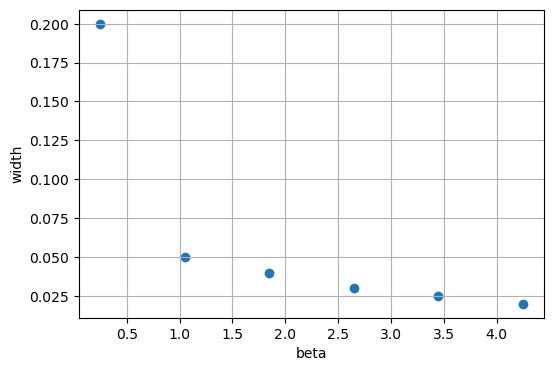

In [8]:
L = 16
betas = np.linspace(start=0.25, stop=4.25, num=6)
theta0 = np.zeros(shape=(2, L, L))
widths_candidates = [0.01, 0.02, 0.1, 0.2, 0.05, 0.04, 0.03, 0.07, 0.025]
rng = np.random.default_rng(seed=42)

best_widths = []
goal_acceptance_min = 0.65
goal_acceptance_max = 0.75
number_of_samples = 1500

for beta in betas:
    best_width = None
    best_acceptance = 0

    for width in widths_candidates:
        charge, acceptance = sample_field(theta0, number_of_samples, beta, width, rng)
        acceptance_rate = np.mean(acceptance)

        if goal_acceptance_min <= acceptance_rate <= goal_acceptance_max:
            best_width = width
            break 

    best_widths.append(best_width)

best_width_dict = {}

for beta, best in zip(betas, best_widths): 
    print(f"For $$\\beta$$ = {beta:.3f}, the best widths is {best}.")
    best_width_dict[f"beta{beta}"] = best

plt.figure(figsize = (6, 4))
plt.scatter(betas, best_widths)
plt.xlabel("beta")
plt.ylabel("width")
plt.grid(True)

### 3.2 Sample generation

Having found the width for each $\beta$, generate a large number of samples (17,000 - 25,000 or more, if time allows) for each $\beta$ and store them.

In [ ]:
import numpy as np
from tqdm import tqdm

L = 16
betas = np.linspace(start=0.25, stop=4.25, num=6)
theta0 = np.zeros(shape=(2, L, L))
rng = np.random.default_rng(seed=42)

best_widths = []
number_of_samples = 25_000

beta_data_dict = {}

for beta in tqdm(betas, desc="Generating samples"):
    width = best_width_dict[f"beta{beta}"]
    charge, acceptance = sample_field(theta0, number_of_samples, beta, width, rng)
    acceptance_rate = np.mean(acceptance)
    beta_data_dict[f"beta{beta}"] = charge

np.savez("charge_measurement_different_beta.npz", **beta_data_dict)
print("Saved data to 'charge_measurement_different_beta.npz' ")

Generating samples: 100%|██████████| 6/6 [00:16<00:00,  2.79s/it]

Saved data to 'charge_measurement_different_beta.npz' 


### 3.3 Analysis

Plot each series of $Q$ separately and answer the following questions:
* What happens to the series of $Q$ as $\beta$ increases?
* What is the largest value of $| Q |$ achieved in each of them?
* How often in the series is $Q_{i + 1} \neq Q_{i}$?

Finally, evaluate the averages $\langle Q \rangle$ and $\langle Q^{2} \rangle$ for each series and compare.

Maxumum |Q| for beta=0.25 is 20.0
Number of changes in Q for beta=0.25 is 15384 out of 25000 samples.
Maxumum |Q| for beta=1.05 is 11.0
Number of changes in Q for beta=1.05 is 6208 out of 25000 samples.
Maxumum |Q| for beta=1.85 is 4.0
Number of changes in Q for beta=1.85 is 1530 out of 25000 samples.
Maxumum |Q| for beta=2.65 is 3.0
Number of changes in Q for beta=2.65 is 300 out of 25000 samples.
Maxumum |Q| for beta=3.45 is 1.0
Number of changes in Q for beta=3.45 is 85 out of 25000 samples.
Maxumum |Q| for beta=4.25 is 0.0
Number of changes in Q for beta=4.25 is 0 out of 25000 samples.
Beta=0.25: <Q>=0.3841 $\pm$ 4.2126, <Q^2>=17.8936 $\pm$ 25.6231
Beta=1.05: <Q>=0.3014 $\pm$ 3.3399, <Q^2>=11.2461 $\pm$ 16.2591
Beta=1.85: <Q>=0.0672 $\pm$ 1.7326, <Q^2>=3.0064 $\pm$ 4.0435
Beta=2.65: <Q>=0.5989 $\pm$ 0.8455, <Q^2>=1.0735 $\pm$ 1.3729
Beta=3.45: <Q>=-0.0450 $\pm$ 0.2909, <Q^2>=0.0866 $\pm$ 0.2813
Beta=4.25: <Q>=0.0000 $\pm$ 0.0000, <Q^2>=0.0000 $\pm$ 0.0000


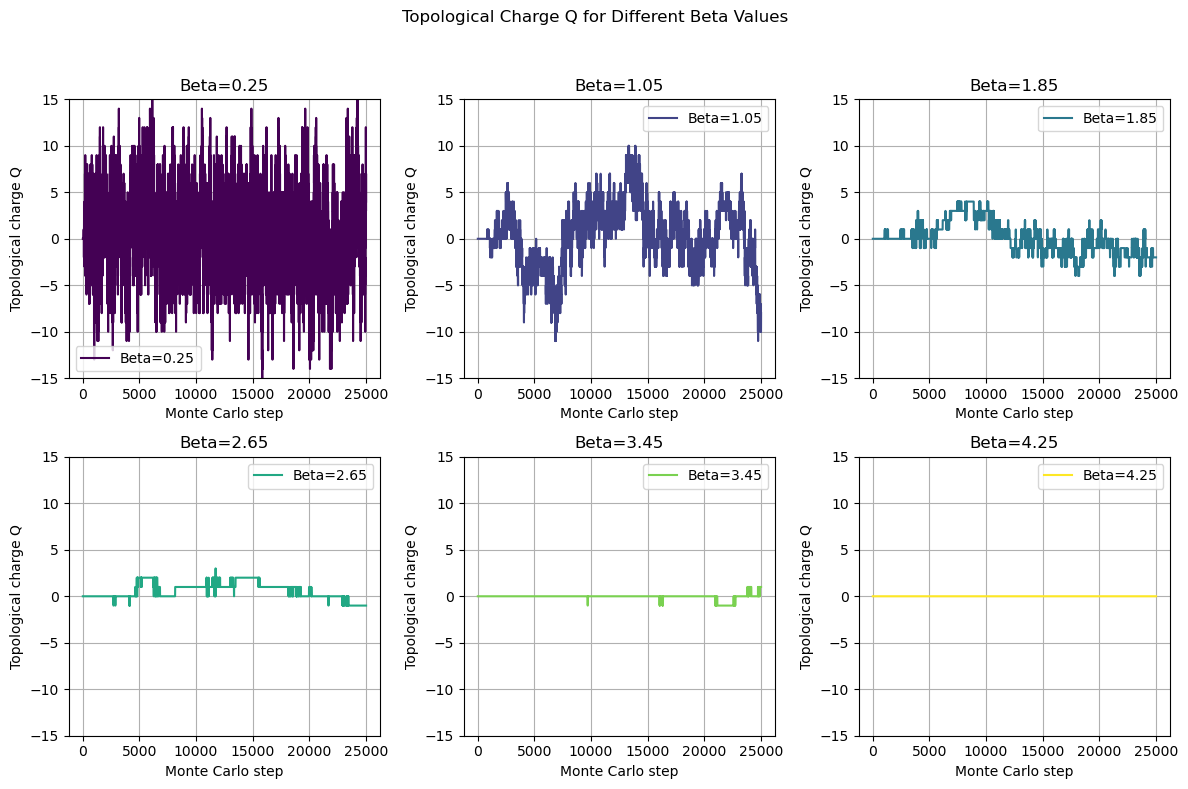

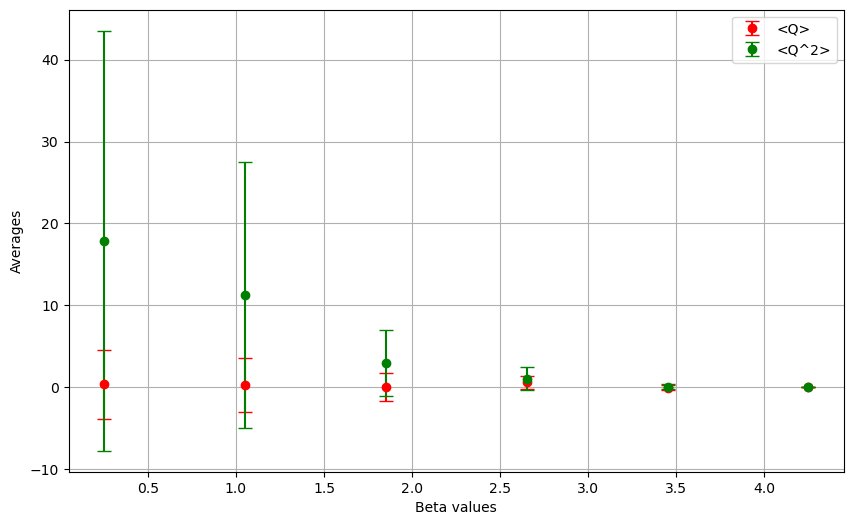

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("charge_measurement_different_beta.npz")

colors = plt.cm.viridis(np.linspace(0, 1, len(data.keys())))
for key, color in zip(sorted(data.keys(), key=lambda x: float(x.replace("beta", ""))), colors):
    measurements = data[key]
    print(f"Maxumum |Q| for beta={float(key.replace('beta', '')):.2f} is {np.max(np.abs(measurements))}") #the maximum of |Q| in the series
    #how often in the series is Q_i != Q_{i-1}??
    changes = np.sum(np.abs(np.diff(measurements)) > 0)
    print(f"Number of changes in Q for beta={float(key.replace('beta', '')):.2f} is {changes} out of {len(measurements)} samples.")


fig, axes = plt.subplots(2, 3, figsize=(12, 8))
plt.suptitle("Topological Charge Q for Different Beta Values", fontsize=12)

for i, (key, ax) in enumerate(zip(sorted(data.keys(), key=lambda x: float(x.replace("beta", ""))), axes.flatten())):
    measurements = data[key]
    ax.set_ylim(-15, 15)
    ax.plot(range(len(measurements)), measurements, label=f"Beta={float(key.replace('beta', '')):.2f}", c=colors[i])
    ax.set_title(f"Beta={float(key.replace('beta', '')):.2f}")
    ax.set_xlabel("Monte Carlo step")
    ax.set_ylabel("Topological charge Q")
    ax.grid(True)
    ax.legend(fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])

#evaluate the averages and standard deviations for Q and Q^2
avg_Qs = []
std_Qs = []
avg_Q2s = []
std_Q2s = []
for key in sorted(data.keys(), key=lambda x: float(x.replace("beta", ""))):
    charges_measured = data[key]
    avg_Q = np.mean(charges_measured)
    std_Q = np.std(charges_measured)
    avg_Q2 = np.mean(np.array(charges_measured)**2)
    std_Q2 = np.std(np.array(charges_measured)**2)
    avg_Qs.append(avg_Q)
    std_Qs.append(std_Q)
    avg_Q2s.append(avg_Q2)
    std_Q2s.append(std_Q2)
    print(f"Beta={float(key.replace('beta', '')):.2f}: <Q>={avg_Q:.4f} $\\pm$ {std_Q:.4f}, <Q^2>={avg_Q2:.4f} $\\pm$ {std_Q2:.4f}")

plt.figure(figsize= (10, 6))
beta = [float(key.replace("beta", "")) for key in sorted(data.keys(), key=lambda x: float(x.replace("beta", "")))]
plt.errorbar(beta, avg_Qs, yerr=std_Qs, fmt='o', capsize=5, label="<Q>",c = "r")
plt.errorbar(beta, avg_Q2s, yerr=std_Q2s, fmt='o', capsize=5, label="<Q^2>", c = "green")
plt.xlabel("Beta values", fontsize=10)
plt.ylabel("Averages", fontsize=10 )
plt.legend()
plt.grid(True)
plt.show()

the theory has varoious differnet top. charges. the way we sample only explores one sort of conf. where Q = 0 for high betas. We see now that this is a problem. 

increasing beta corresponds to make a finer lattice spacing, we want to be able to do this without introducing the above bias. 

with HMC instead of Metropolis this is better! in research: simple ML methods to learn how to avoid topological freezing. difficult to implement for SU(3), it is often done for U(1) in 2D. 